In [41]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px

# ---- Load artifacts ----
results_df = joblib.load("artifacts/results_df.joblib")
best_models = joblib.load("artifacts/best_models.joblib")
feat_importances = joblib.load("artifacts/feat_importances.joblib")
lin_coef_df = joblib.load("artifacts/lin_coef_df.joblib")
splits = joblib.load("artifacts/splits.joblib")

In [42]:
type(results_df)         # pandas.DataFrame
type(best_models)        # dict
results_df

,model,target_scale,cv_MAE,cv_RMSE,cv_R2,test_MAE,test_RMSE,test_R2,test_adj_R2
0,XGBoost,log,38446.970864,57627.695474,0.906742,30527.649637,44480.025494,0.946208,0.946135
1,XGBoost,raw,38297.371569,56837.441483,0.909460,30652.476129,44581.352685,0.945962,0.945889
2,CatBoost,raw,38532.355529,57001.546433,0.908769,30983.862931,44802.263688,0.945426,NaN
3,CatBoost,log,38674.023219,58014.437866,0.905293,30800.378952,44888.447883,0.945215,NaN
4,RandomForest,raw,39337.169414,58977.214018,0.902799,32161.447196,48440.128828,0.936203,0.936117
5,RandomForest,log,39742.502009,59717.903643,0.900327,32306.060994,48693.925263,0.935533,0.935445
6,Linear,raw,84038.935246,116823.379581,0.625885,84533.213660,115920.903228,0.634647,0.634151
7,Linear,log,82948.816638,126738.562847,0.556301,82547.475516,119095.317240,0.614363,0.613840


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume you've already loaded your results_df
# results_df = joblib.load("artifacts/results_df.joblib")

# --- Clean + format the table ---
tbl = results_df.copy()

# Round large numeric values
cols_to_round = ["cv_MAE","cv_RMSE","test_MAE","test_RMSE"]
tbl[cols_to_round] = tbl[cols_to_round].applymap(lambda x: f"{x:,.0f}")
tbl[["cv_R2","test_R2","test_adj_R2"]] = tbl[["cv_R2","test_R2","test_adj_R2"]].applymap(lambda x: f"{x:.3f}" if pd.notna(x) else "–")

# Rename columns for readability
tbl = tbl.rename(columns={
    "model": "Model",
    "target_scale": "Target",
    "cv_MAE": "CV MAE",
    "cv_RMSE": "CV RMSE",
    "cv_R2": "CV R²",
    "test_MAE": "Test MAE",
    "test_RMSE": "Test RMSE",
    "test_R2": "Test R²",
    "test_adj_R2": "Adj R²"
})

# Sort by best R² descending
tbl = tbl.sort_values("Test R²", ascending=False).reset_index(drop=True)

# Preview
print(tbl)

          Model Target  CV MAE  CV RMSE  CV R² Test MAE Test RMSE Test R²  \
0       XGBoost    log  38,447   57,628  0.907   30,528    44,480   0.946   
1       XGBoost    raw  38,297   56,837  0.909   30,652    44,581   0.946   
2      CatBoost    raw  38,532   57,002  0.909   30,984    44,802   0.945   
3      CatBoost    log  38,674   58,014  0.905   30,800    44,888   0.945   
4  RandomForest    raw  39,337   58,977  0.903   32,161    48,440   0.936   
5  RandomForest    log  39,743   59,718  0.900   32,306    48,694   0.936   
6        Linear    raw  84,039  116,823  0.626   84,533   115,921   0.635   
7        Linear    log  82,949  126,739  0.556   82,547   119,095   0.614   

  Adj R²  
0  0.946  
1  0.946  
2      –  
3      –  
4  0.936  
5  0.935  
6  0.634  
7  0.614  


/var/folders/wr/mslv0h8d73n9kkgc30xk05lm0000gn/T/ipykernel_37784/2003351597.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tbl[cols_to_round] = tbl[cols_to_round].applymap(lambda x: f"{x:,.0f}")
/var/folders/wr/mslv0h8d73n9kkgc30xk05lm0000gn/T/ipykernel_37784/2003351597.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tbl[["cv_R2","test_R2","test_adj_R2"]] = tbl[["cv_R2","test_R2","test_adj_R2"]].applymap(lambda x: f"{x:.3f}" if pd.notna(x) else "–")


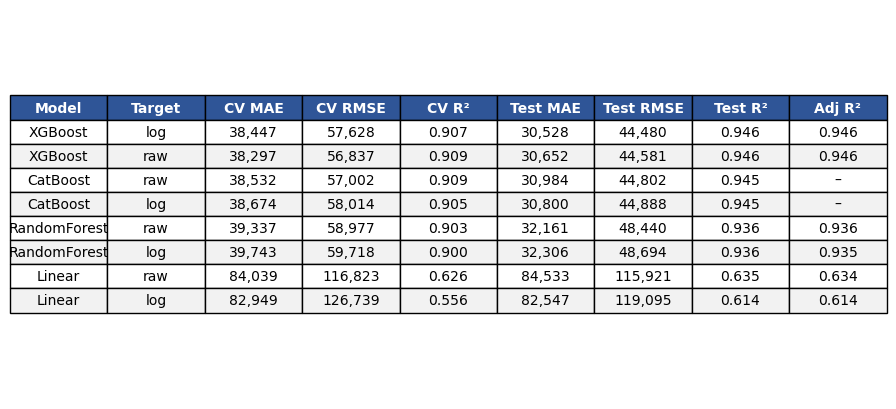

In [44]:
fig, ax = plt.subplots(figsize=(9, 1.8 + 0.3*len(tbl)))
ax.axis("off")

# Render the table
mpl_table = ax.table(
    cellText=tbl.values,
    colLabels=tbl.columns,
    cellLoc='center',
    loc='center'
)

# Style
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(10)
mpl_table.scale(1.2, 1.2)

# Optional styling: bold headers
for (row, col), cell in mpl_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#2F5597")  # dark blue header
    elif row % 2 == 0:
        cell.set_facecolor("#F2F2F2")  # light gray alternation
    else:
        cell.set_facecolor("white")

plt.tight_layout()
plt.savefig("model_results_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
results_df = results_df.sort_values("test_R2", ascending=False)
print(results_df[["model","target_scale","test_MAE","test_RMSE","test_R2"]])

          model target_scale      test_MAE      test_RMSE   test_R2
0       XGBoost          log  30527.649637   44480.025494  0.946208
1       XGBoost          raw  30652.476129   44581.352685  0.945962
2      CatBoost          raw  30983.862931   44802.263688  0.945426
3      CatBoost          log  30800.378952   44888.447883  0.945215
4  RandomForest          raw  32161.447196   48440.128828  0.936203
5  RandomForest          log  32306.060994   48693.925263  0.935533
6        Linear          raw  84533.213660  115920.903228  0.634647
7        Linear          log  82547.475516  119095.317240  0.614363


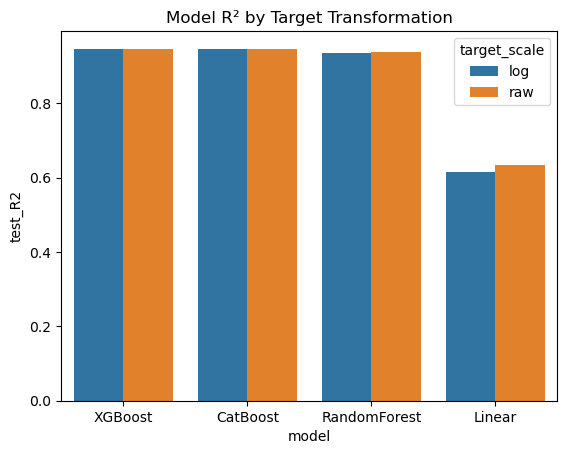

In [46]:
import seaborn as sns, matplotlib.pyplot as plt

sns.barplot(data=results_df, x="model", y="test_R2", hue="target_scale")
plt.title("Model R² by Target Transformation")
plt.show()


RandomForest top features:
floor_area_sqm         0.573076
Latitude               0.105664
Longitude              0.057929
t_idx                  0.047715
dist_m_cycling_path    0.034177
dist_m_mrt_exit        0.027032
dist_m_tourist         0.021299
dist_m_gym             0.018716
dist_m_supermarket     0.017116
dist_m_hawker          0.015243
dtype: float64


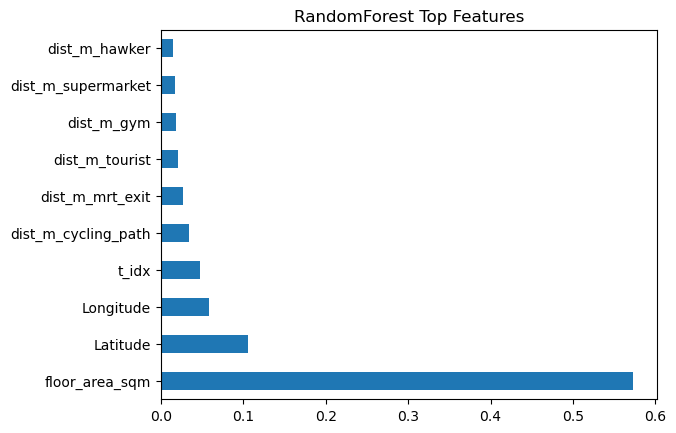


XGBoost top features:
town_JURONG WEST      0.117922
town_YISHUN           0.087920
town_QUEENSTOWN       0.075454
town_BISHAN           0.069352
floor_area_sqm        0.055140
town_CHOA CHU KANG    0.052887
town_BUKIT BATOK      0.042949
town_PUNGGOL          0.041922
town_TAMPINES         0.040327
town_TOA PAYOH        0.038957
dtype: float32


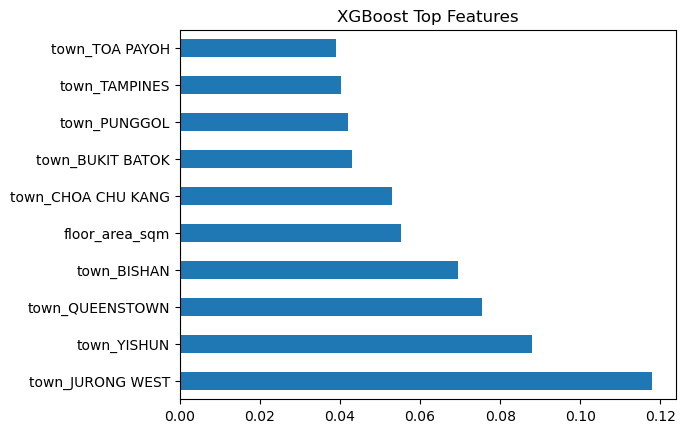


CatBoost top features:
floor_area_sqm         37.328487
Latitude               15.650639
Longitude               8.058459
town                    7.222314
dist_m_cycling_path     4.084698
dist_m_taxi_stop        3.809553
dist_m_mrt_exit         3.769405
t_idx                   3.647669
dist_m_supermarket      2.974152
dist_m_hawker           2.744339
dtype: float64


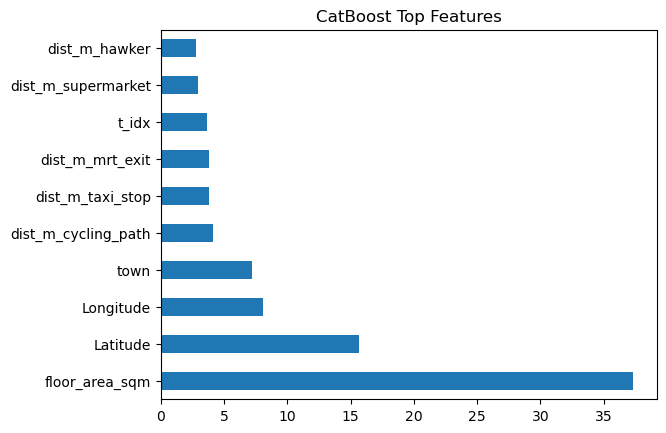

In [47]:
for model, imp in feat_importances.items():
    print(f"\n{model} top features:")
    print(imp.head(10))
    imp.head(10).plot(kind="barh", title=f"{model} Top Features")
    plt.show()

In [48]:
lin_coef_df.sort_values("coefficient", ascending=False).head(10)

,feature,coefficient
0,floor_area_sqm,144682.550138
1,town_BUKIT MERAH,35838.320734
2,dist_m_tourist,33645.995143
3,t_idx,32783.653667
4,town_QUEENSTOWN,25916.328847
5,town_TOA PAYOH,23608.400156
6,town_KALLANG/WHAMPOA,23002.682633
7,town_CENTRAL AREA,18974.986613
8,town_BISHAN,17367.828617
9,dist_m_school,15289.761432


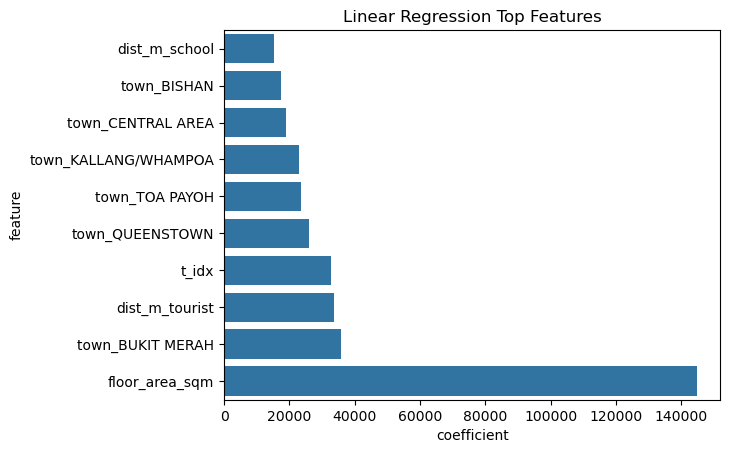

In [63]:
sns.barplot(
    data=lin_coef_df.sort_values("coefficient", ascending=True).tail(10),
    y="feature", x="coefficient"
)
plt.title("Linear Regression Top Features")
plt.show()

In [50]:
cat_model = best_models["CatBoost"]["estimator"]  # example
X_new = splits["X_test"] if isinstance(splits, dict) else None  # depends on how you saved it
y_pred = cat_model.predict(X_new)

In [51]:
import joblib, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ART = Path("artifacts")  # change if needed
DATA = Path("/Users/uddashyakumar/Library/CloudStorage/OneDrive-TheUniversityofHongKong-Connect/y3/Sem 2/COMP3522/PM3/Data")

# Artifacts
results_df     = joblib.load(ART / "results_df.joblib")
best_models    = joblib.load(ART / "best_models.joblib")
feat_import    = joblib.load(ART / "feat_importances.joblib")
lin_coef_df    = joblib.load(ART / "lin_coef_df.joblib")
splits         = joblib.load(ART / "splits.joblib")

# Base table (for coordinates / features)
df_all = pd.read_parquet(DATA / "resale_2021plus_with_amenity_distances.parquet")

# Recover X_train/X_test etc. from splits (your script likely saved dict-like)
X_train = splits.get("X_train") if isinstance(splits, dict) else None
X_test  = splits.get("X_test")
y_train = splits.get("y_train")
y_test  = splits.get("y_test")

# Pick the best overall model for visuals (CatBoost preferred if present)
model_name = "CatBoost" if "CatBoost" in best_models else ("XGBoost" if "XGBoost" in best_models else "RandomForest")
best_bundle = best_models[model_name]
best_est    = best_bundle["estimator"]
is_log      = (best_bundle.get("target_scale","raw") == "log")

# Predictions on test set (back-transform if log)
y_pred = best_est.predict(X_test)
if is_log:
    y_pred = np.expm1(y_pred)

# Attach coords to X_test view (for maps)
cols_to_keep = [c for c in ["Latitude","Longitude","town","region","postal_district","dist_m_mrt_exit","dist_m_supermarket"] if c in X_test.columns]
viz_df = X_test[cols_to_keep].copy()
viz_df["actual"] = y_test.values
viz_df["pred"]   = y_pred
viz_df["resid"]  = viz_df["actual"] - viz_df["pred"]

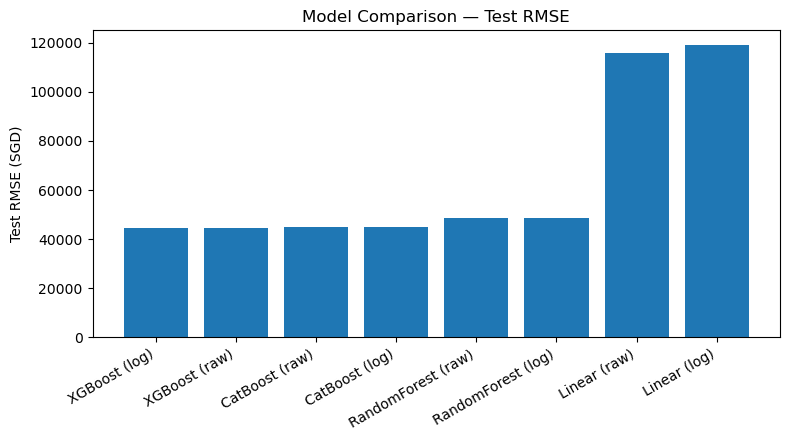

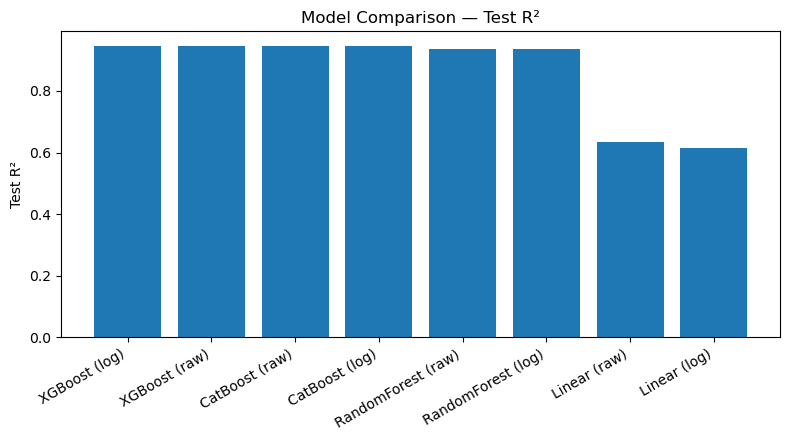

In [52]:
def plot_model_comparison(res_df: pd.DataFrame, savepath: str | None = None):
    res = res_df.copy()
    res = res.sort_values("test_RMSE")
    labels = [f"{m} ({t})" for m, t in zip(res["model"], res["target_scale"])]
    rmse   = res["test_RMSE"].to_numpy()
    r2     = res["test_R2"].to_numpy()

    # RMSE
    plt.figure(figsize=(8,4.5))
    plt.bar(range(len(labels)), rmse)
    plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("Test RMSE (SGD)")
    plt.title("Model Comparison — Test RMSE")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

    # R2
    plt.figure(figsize=(8,4.5))
    plt.bar(range(len(labels)), r2)
    plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
    plt.ylabel("Test R²")
    plt.title("Model Comparison — Test R²")
    plt.tight_layout()
    if savepath: 
        p = Path(savepath); plt.savefig(p.with_name(p.stem + "_r2.png"), dpi=200)
    plt.show()

plot_model_comparison(results_df, "model_comparison_rmse.png")

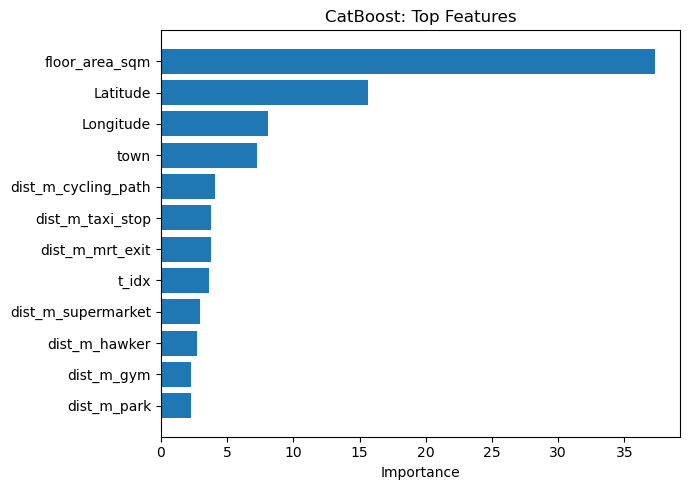

In [53]:
def plot_top_importance(imp_series: pd.Series, top: int = 12, title: str = "", savepath: str | None = None):
    imp = imp_series.sort_values(ascending=True).tail(top)  # ascending so bars go upward
    plt.figure(figsize=(7,5))
    plt.barh(imp.index, imp.values)
    plt.xlabel("Importance")
    plt.title(title or "Top Features")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

plot_top_importance(
    feat_import[model_name], 
    top=12, 
    title=f"{model_name}: Top Features", 
    savepath=f"{model_name.lower()}_top_features.png"
)

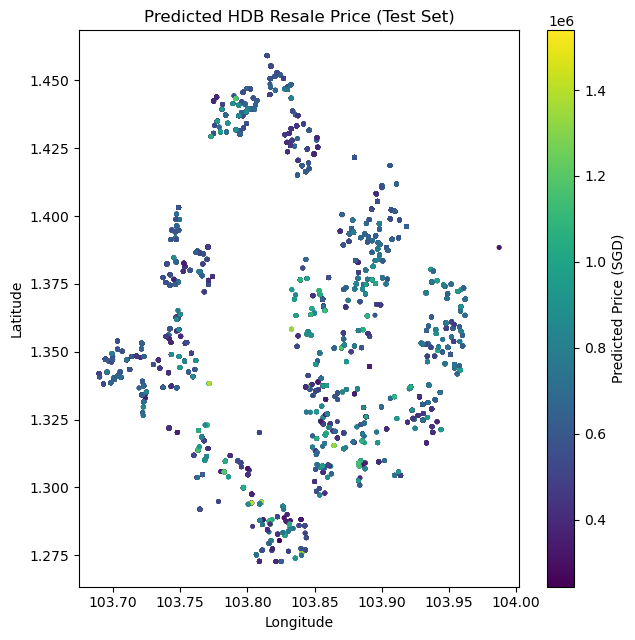

In [54]:
def plot_price_map(df_map: pd.DataFrame, savepath: str | None = None):
    m = df_map.dropna(subset=["Latitude","Longitude","pred"])
    plt.figure(figsize=(6.5,6.5))
    plt.scatter(m["Longitude"], m["Latitude"], c=m["pred"], s=6)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Predicted HDB Resale Price (Test Set)")
    cb = plt.colorbar()
    cb.set_label("Predicted Price (SGD)")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

plot_price_map(viz_df, "map_predicted_price.png")

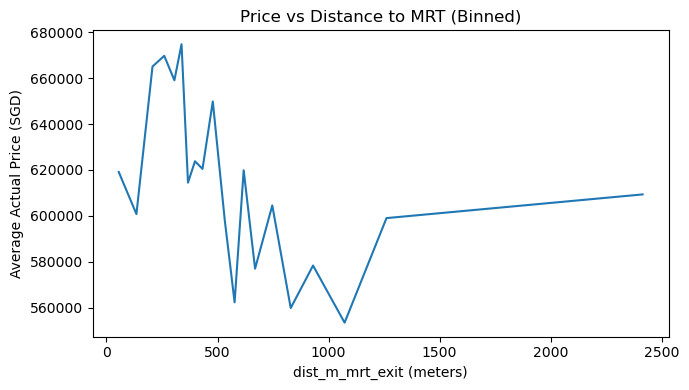

In [55]:
def plot_price_vs_distance(dfv: pd.DataFrame, dist_col: str = "dist_m_mrt_exit", savepath: str | None = None):
    if dist_col not in dfv.columns:
        return
    d = dfv[[dist_col, "actual"]].dropna().sort_values(dist_col)
    # bin by quantiles
    q = np.linspace(0, 1, 21)  # 20 bins
    cuts = d[dist_col].quantile(q).to_numpy()
    # midpoints for x
    mids = (cuts[:-1] + cuts[1:]) / 2
    means = []
    for a, b in zip(cuts[:-1], cuts[1:]):
        mask = (d[dist_col] >= a) & (d[dist_col] < b)
        means.append(d.loc[mask, "actual"].mean())
    means = np.array(means)

    plt.figure(figsize=(7,4))
    plt.plot(mids, means)
    plt.xlabel(f"{dist_col} (meters)")
    plt.ylabel("Average Actual Price (SGD)")
    plt.title("Price vs Distance to MRT (Binned)")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

plot_price_vs_distance(viz_df, "dist_m_mrt_exit", "price_vs_mrt_distance.png")

In [56]:
def plot_box_residuals(dfv: pd.DataFrame, by: str = "region", top_n: int = 8, savepath: str | None = None):
    d = dfv.copy()
    if by not in d.columns:
        return
    if by == "town":
        # keep top_n towns by count for a readable plot
        top = d["town"].value_counts().index[:top_n]
        d = d[d["town"].isin(top)]

    groups = [g["resid"].dropna().values for _, g in d.groupby(by)]
    labels = [str(k) for k,_ in d.groupby(by)]

    plt.figure(figsize=(8,4.5))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.axhline(0, linestyle="--")
    plt.ylabel("Residual = Actual - Predicted (SGD)")
    plt.title(f"Residuals by {by.upper()}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

# try region first; if you didn’t add region yet, switch to town
plot_box_residuals(viz_df, by="region", savepath="residuals_by_region.png")

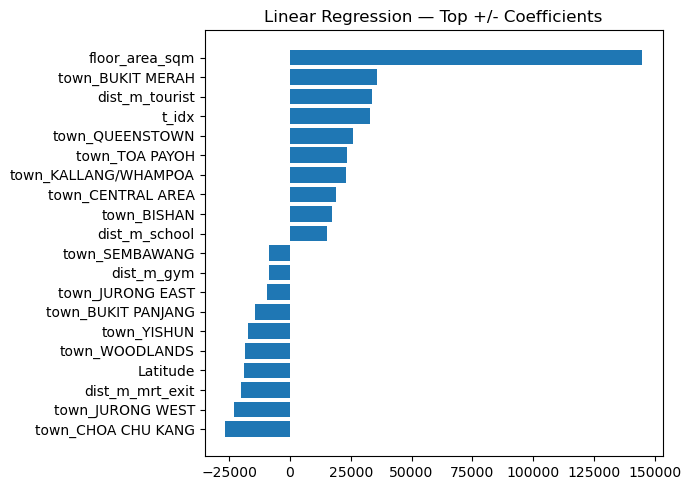

In [57]:
def plot_linear_coefs(coef_df: pd.DataFrame, top: int = 10, savepath: str | None = None):
    if coef_df is None or coef_df.empty: 
        return
    c = coef_df.copy()
    c = c.sort_values("coefficient")
    neg = c.head(top)
    pos = c.tail(top)
    show = pd.concat([neg, pos])
    plt.figure(figsize=(7,5))
    plt.barh(show["feature"], show["coefficient"])
    plt.title("Linear Regression — Top +/- Coefficients")
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=200)
    plt.show()

plot_linear_coefs(lin_coef_df, top=10, savepath="linear_top_coefs.png")

## Overfitting Analysis
We compare each retained model's performance on the training split versus the hold-out split to gauge potential overfitting.

In [58]:
# Ensure we have direct access to the train/test splits
X_train = splits['X_train'].copy()
X_test = splits['X_test'].copy()
y_train = splits['y_train'].astype(float).copy()
y_test = splits['y_test'].astype(float).copy()


In [59]:
# Compute train vs test metrics for each model in best_models
overfit_rows = []
for model_label, bundle in best_models.items():
    estimator = bundle['estimator']
    target_scale = bundle.get('target_scale', 'raw')

    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    if target_scale == 'log':
        train_pred = np.expm1(train_pred)
        test_pred = np.expm1(test_pred)

    # older sklearn versions may not accept `squared` kwarg; compute RMSE via sqrt of MSE
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    overfit_rows.append({
        'model': model_label,
        'target_scale': target_scale,
        'train_RMSE': train_rmse,
        'test_RMSE': test_rmse,
        'rmse_gap': test_rmse - train_rmse,
        'train_MAE': train_mae,
        'test_MAE': test_mae,
        'mae_gap': test_mae - train_mae,
        'train_R2': train_r2,
        'test_R2': test_r2,
        'r2_gap': train_r2 - test_r2,
    })
overfit_df = pd.DataFrame(overfit_rows).sort_values('rmse_gap', ascending=False).reset_index(drop=True)
overfit_df

,model,target_scale,train_RMSE,test_RMSE,rmse_gap,train_MAE,test_MAE,mae_gap,train_R2,test_R2,r2_gap
0,RandomForest,raw,26454.935955,48440.128828,21985.192873,17398.818121,32161.447196,14762.629075,0.980539,0.936203,0.044336
1,XGBoost,log,34006.259355,44480.025494,10473.766139,23864.814757,30527.649637,6662.834880,0.967844,0.946208,0.021636
2,CatBoost,raw,38521.268281,44802.263688,6280.995407,27374.348636,30983.862931,3609.514295,0.958738,0.945426,0.013313
3,Linear,raw,112321.680873,115920.903228,3599.222355,82592.735075,84533.213660,1940.478585,0.649190,0.634647,0.014543


In [60]:
# Visualise the generalisation gap using Plotly
fig_gap = px.bar(
    overfit_df,
    x='model',
    y='rmse_gap',
    color='rmse_gap',
    color_continuous_scale='RdYlGn_r',
    text=overfit_df['rmse_gap'].map(lambda v: f"{v:,.0f}"),
    title='Hold-out vs Training RMSE Gap (smaller is better)',
    labels={'model': 'Model', 'rmse_gap': 'Test RMSE − Train RMSE'}
)
fig_gap.update_traces(textposition='outside')
fig_gap.update_layout(yaxis=dict(title='RMSE Gap (SGD)'), xaxis={'title': 'Model'}, uniformtext_minsize=8, uniformtext_mode='hide')
fig_gap


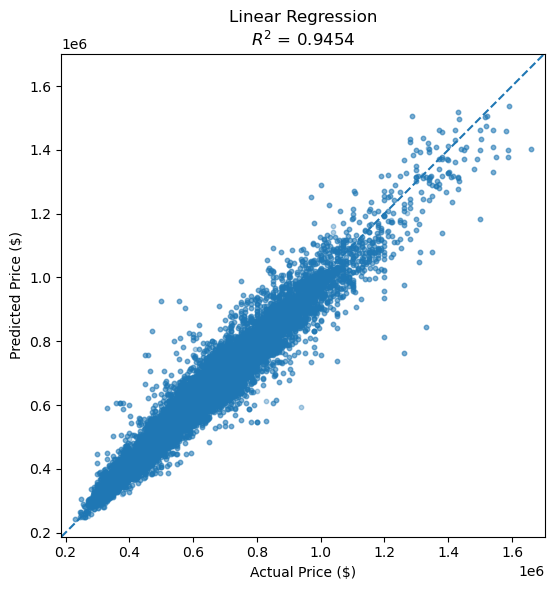

Saved figure → linreg_actual_vs_pred.png


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_pred(y_true, y_pred, model_name="Linear Regression", savepath="actual_vs_pred.png"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # Axis limits (same for x & y for a fair visual)
    lo = float(np.nanmin([y_true.min(), y_pred.min()]))
    hi = float(np.nanmax([y_true.max(), y_pred.max()]))
    pad = 0.03 * (hi - lo)
    lo, hi = lo - pad, hi + pad

    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    # scatter of predictions vs actuals
    plt.scatter(y_true, y_pred, s=10, alpha=0.35)

    # 45° reference line (perfect predictions)
    line = np.linspace(lo, hi, 200)
    plt.plot(line, line, linestyle="--")

    # labels & title
    plt.xlabel("Actual Price ($)")
    plt.ylabel("Predicted Price ($)")
    plt.title(f"{model_name}\n$R^2$ = {r2:.4f}")

    # square aspect and tight layout for PPT
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()

    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure → {savepath}")

# Example usage (replace y_test, y_pred with yours):
plot_actual_vs_pred(y_test, y_pred, model_name="Linear Regression", savepath="linreg_actual_vs_pred.png")